# Eksperimen Komparasi PSO vs WCPSO vs APSO vs ADIWAKO-Stable
**Rosa Nur Aliana Sawafi — 2311110008**  
Program Studi S1 Sains Data, Universitas Telkom Purwokerto

---
## Spesifikasi
- **Algoritma:** PSO, WCPSO, APSO, ADIWAKO-Stable
- **Benchmark:** 10 fungsi (Rastrigin, Styblinski-Tang, Levy N.13, Schwefel 2.22, Michalewicz, Zakharov, Ackley, Alpine, Beale's, Booth's)
- **Parameter:** n_particles=500, max_iter=1000, n_runs=10
- **Output:** 1 file Excel per benchmark function + grafik konvergensi

---
## Keterangan Benchmark

| No | Fungsi | Tipe | Dimensi | f* | Sumber |
|---|---|---|---|---|---|
| 1 | Rastrigin | Multimodal | 20D | 0 | Naser et al. (2024) |
| 2 | Styblinski-Tang | Multimodal | 2D | -78.332 | Naser et al. (2024) |
| 3 | Levy N.13 | Multimodal | 2D | 0 | Naser et al. (2024) |
| 4 | Schwefel 2.22 | Unimodal | 20D | 0 | Naser et al. (2024) |
| 5 | Michalewicz | Multimodal | 10D | ≈-9.66 | Naser et al. (2024) |
| 6 | Zakharov | Unimodal | 20D | 0 | Naser et al. (2024) |
| 7 | Ackley | Multimodal | 20D | 0 | Naser et al. (2024) |
| 8 | Alpine N.1 | Multimodal | 10D | 0 | Naser et al. (2024) |
| 9 | Beale's | Multimodal | 2D | 0 | Naser et al. (2024) |
| 10 | Booth's | Unimodal | 2D | 0 | Naser et al. (2024) |

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## BAGIAN 1: Implementasi Algoritma

### 1.1 Standard PSO (Kennedy & Eberhart, 1995)
### 1.2 WCPSO — PSO with Constriction Factor (Clerc & Kennedy, 2002)
### 1.3 APSO — Adaptive PSO (Zhan et al., 2009)
### 1.4 ADIWAKO-Stable — Sekyere et al. (2024) + stabilitas numerik Python

In [2]:
# ══════════════════════════════════════════════════════════
# DEFINISI ALGORITMA + KONFIGURASI (dalam satu cell)
# Jalankan PERTAMA sebelum cell lainnya
# ══════════════════════════════════════════════════════════

import numpy as np

# ──────────────────────────────────────────────────────────
# 1. Standard PSO
# ──────────────────────────────────────────────────────────
class PSO:
    """Standard PSO — Kennedy & Eberhart (1995). w=0.729, c1=c2=1.494"""
    def __init__(self, n_particles=500, max_iter=1000,
                 w=0.729, c1=1.494, c2=1.494, bounds=None, **kwargs):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.w=w; self.c1=c1; self.c2=c2; self.bounds=bounds

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds])
        ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost)
        gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]; conv_iter=self.max_iter
        for t in range(self.max_iter):
            r1=np.random.rand(self.n_particles,n_dim)
            r2=np.random.rand(self.n_particles,n_dim)
            vel=(self.w*vel+self.c1*r1*(pbest_pos-pos)+self.c2*r2*(gbest_pos-pos))
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost
            pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost:
                gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy(); conv_iter=t+1
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history, conv_iter


# ──────────────────────────────────────────────────────────
# 2. WCPSO — PSO with Constriction Factor
# ──────────────────────────────────────────────────────────
class WCPSO:
    """WCPSO — Clerc & Kennedy (2002). Constriction factor chi=0.7298"""
    def __init__(self, n_particles=500, max_iter=1000,
                 c1=2.05, c2=2.05, bounds=None, **kwargs):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.c1=c1; self.c2=c2
        phi=c1+c2
        self.chi=2.0/abs(2.0-phi-np.sqrt(phi**2-4*phi))
        self.bounds=bounds

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds])
        ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost)
        gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]; conv_iter=self.max_iter
        for t in range(self.max_iter):
            r1=np.random.rand(self.n_particles,n_dim)
            r2=np.random.rand(self.n_particles,n_dim)
            vel=self.chi*(vel+self.c1*r1*(pbest_pos-pos)+self.c2*r2*(gbest_pos-pos))
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost
            pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost:
                gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy(); conv_iter=t+1
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history, conv_iter


# ──────────────────────────────────────────────────────────
# 3. APSO — Adaptive PSO
# ──────────────────────────────────────────────────────────
class APSO:
    """APSO — Zhan et al. (2009). Adaptive inertia + Elitist Learning Strategy"""
    def __init__(self, n_particles=500, max_iter=1000,
                 w_max=0.9, w_min=0.4, c1=2.0, c2=2.0,
                 bounds=None, **kwargs):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.w_max=w_max; self.w_min=w_min
        self.c1=c1; self.c2=c2; self.bounds=bounds

    def _adapt_w(self, pbest_cost, gbest_cost, w_cur):
        spread=np.mean(np.abs(pbest_cost-gbest_cost))/(np.abs(gbest_cost)+1e-10)
        f=float(np.clip(1.0-spread,0,1))
        if f>0.7:   return max(w_cur-0.05, self.w_min)
        elif f<0.3: return min(w_cur+0.05, self.w_max)
        return w_cur

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds])
        ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost)
        gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]; conv_iter=self.max_iter; w_cur=self.w_max
        for t in range(self.max_iter):
            w_cur=self._adapt_w(pbest_cost,gbest_cost,w_cur)
            r1=np.random.rand(self.n_particles,n_dim)
            r2=np.random.rand(self.n_particles,n_dim)
            vel=(w_cur*vel+self.c1*r1*(pbest_pos-pos)+self.c2*r2*(gbest_pos-pos))
            pos=np.clip(pos+vel,lb,ub)
            if np.random.rand()<0.1:
                sigma=(ub-lb)*np.exp(-t/self.max_iter)
                new_pos=np.clip(gbest_pos+sigma*np.random.randn(n_dim),lb,ub)
                new_cost=fitness_func(new_pos)
                if new_cost<gbest_cost:
                    gbest_cost=new_cost; gbest_pos=new_pos.copy()
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost
            pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost:
                gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy(); conv_iter=t+1
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history, conv_iter


# ──────────────────────────────────────────────────────────
# 4. ADIWAKO-Stable
# ──────────────────────────────────────────────────────────
class ADIWAKO_Stable:
    """
    ADIWAKO — Sekyere et al. (2024) + stabilitas numerik Python.
    Formula inti TIDAK BOLEH DIUBAH:
        mu=...[Eq.4], delta=...[Eq.5], w=mu*tanh(delta)[Eq.3]
        psi=...[Eq.7], c1=c2=mu*cosh(psi)[Eq.6]
    """
    def __init__(self, n_particles=500, max_iter=1000,
                 W_max=1.0, W_min=0.1, C_max=5.0, C_min=2.0,
                 bounds=None, mu_min=0.01, c_clip_max=2.5, v_coef=0.1,
                 **kwargs):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.W_max=W_max; self.W_min=W_min
        self.C_max=C_max; self.C_min=C_min
        self.bounds=bounds
        self.mu_min=mu_min; self.c_clip_max=c_clip_max; self.v_coef=v_coef

    def _adaptive_params(self, t, pbest_costs, gbest_cost):
        safe=np.where(np.abs(pbest_costs)<1e-10,1e-10,pbest_costs)
        mu=np.clip((pbest_costs-gbest_cost)/safe, self.mu_min, None)
        delta=self.W_max-(self.W_max-self.W_min)*t/self.max_iter
        w=mu*np.tanh(delta)
        psi=self.C_max-(self.C_max-self.C_min)*t/self.max_iter
        c=np.clip(mu*np.cosh(psi), 0, self.c_clip_max)
        return w, c

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds])
        ub=np.array([b[1] for b in bounds])
        v_max=self.v_coef*(ub-lb)
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost)
        gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]; conv_iter=self.max_iter
        for t in range(1, self.max_iter+1):
            w,c=self._adaptive_params(t,pbest_cost,gbest_cost)
            w=w.reshape(-1,1); c=c.reshape(-1,1)
            r1=np.random.rand(self.n_particles,n_dim)
            r2=np.random.rand(self.n_particles,n_dim)
            vel=w*vel+c*r1*(pbest_pos-pos)+c*r2*(gbest_pos-pos)
            vel=np.clip(vel,-v_max,v_max)
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost
            pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost:
                gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy(); conv_iter=t
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history, conv_iter


# ══════════════════════════════════════════════════════════
# KONFIGURASI EKSPERIMEN
# ══════════════════════════════════════════════════════════

selected_benchmarks = [
    'Rastrigin',       # Multimodal, 20D, f*=0
    'Styblinski-Tang', # Multimodal, 2D,  f*=-78.332
    'Levy-N13',        # Multimodal, 2D,  f*=0
    'Schwefel-2.22',   # Unimodal,   20D, f*=0
    'Michalewicz',     # Multimodal, 10D, f*≈-9.66
    'Zakharov',        # Unimodal,   20D, f*=0
    'Ackley',          # Multimodal, 20D, f*=0
    'Alpine',          # Multimodal, 10D, f*=0
    'Beales',          # Multimodal, 2D,  f*=0
    'Booths',          # Unimodal,   2D,  f*=0
]

N_PARTICLES = 500
MAX_ITER    = 1000
N_RUNS      = 10

# Parameter ADIWAKO — TIDAK BOLEH DIUBAH (formula jurnal)
W_MAX = 1.0;  W_MIN = 0.1
C_MAX = 5.0;  C_MIN = 2.0

# Parameter stabilitas Python — disesuaikan untuk max_iter=1000
MU_MIN     = 0.01
C_CLIP_MAX = 2.5
V_COEF     = 0.1

ALGO_CONFIGS = [
    ('PSO',            PSO,            {'w':0.729,'c1':1.494,'c2':1.494}),
    ('WCPSO',          WCPSO,          {'c1':2.05,'c2':2.05}),
    ('APSO',           APSO,           {'w_max':0.9,'w_min':0.4,'c1':2.0,'c2':2.0}),
    ('ADIWAKO Stable', ADIWAKO_Stable, {
        'W_max':W_MAX,'W_min':W_MIN,'C_max':C_MAX,'C_min':C_MIN,
        'mu_min':MU_MIN,'c_clip_max':C_CLIP_MAX,'v_coef':V_COEF,
    }),
]

# Catatan: validasi selected_benchmarks dilakukan otomatis
# di cell Eksekusi Utama (setelah benchmark functions didefinisikan)

print('=== ALGORITMA & KONFIGURASI SIAP ===')
print(f'  Kelas terdefinisi : PSO, WCPSO, APSO, ADIWAKO_Stable')
print(f'  n_particles       : {N_PARTICLES}')
print(f'  max_iter          : {MAX_ITER}')
print(f'  n_runs            : {N_RUNS}')
print(f'  ADIWAKO (jurnal)  : W_max={W_MAX}, W_min={W_MIN}, C_max={C_MAX}, C_min={C_MIN}')
print(f'  Stabilitas Python : mu_min={MU_MIN}, c_clip_max={C_CLIP_MAX}, v_coef={V_COEF}')
print(f'  Benchmark dipilih : {len(selected_benchmarks)} fungsi')
print(f'  {selected_benchmarks}')
print()
print('Jalankan cell berikutnya (Benchmark Functions) lalu cell Eksekusi Utama.')


=== ALGORITMA & KONFIGURASI SIAP ===
  Kelas terdefinisi : PSO, WCPSO, APSO, ADIWAKO_Stable
  n_particles       : 500
  max_iter          : 1000
  n_runs            : 10
  ADIWAKO (jurnal)  : W_max=1.0, W_min=0.1, C_max=5.0, C_min=2.0
  Stabilitas Python : mu_min=0.01, c_clip_max=2.5, v_coef=0.1
  Benchmark dipilih : 10 fungsi
  ['Rastrigin', 'Styblinski-Tang', 'Levy-N13', 'Schwefel-2.22', 'Michalewicz', 'Zakharov', 'Ackley', 'Alpine', 'Beales', 'Booths']

Jalankan cell berikutnya (Benchmark Functions) lalu cell Eksekusi Utama.


---
## BAGIAN 2: Benchmark Functions
Sumber: Naser et al. (2024) — *A Review of 315 Benchmark Functions*

In [3]:
# ──────────────────────────────────────────────────────────
# Definisi semua benchmark function
# ──────────────────────────────────────────────────────────

def rastrigin(x):
    """Rastrigin | Multimodal | Range:[-5.12,5.12] | f*=0"""
    x = np.asarray(x, float)
    return 10 * len(x) + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def styblinski_tang(x):
    """Styblinski-Tang | Multimodal | Range:[-5,5] | f*=-78.332 (2D)"""
    x = np.asarray(x, float)
    return 0.5 * np.sum(x**4 - 16 * x**2 + 5 * x)

def levy_n13(x):
    """Levy N.13 | Multimodal | Range:[-10,10] | f*=0 (2D)"""
    x = np.asarray(x, float)
    x1, x2 = x[0], x[1]
    return (np.sin(3 * np.pi * x1)**2
            + (x1 - 1)**2 * (1 + np.sin(3 * np.pi * x2)**2)
            + (x2 - 1)**2 * (1 + np.sin(2 * np.pi * x2)**2))

def schwefel_2_22(x):
    """Schwefel 2.22 | Unimodal | Range:[-10,10] | f*=0"""
    x = np.asarray(x, float)
    return np.sum(np.abs(x)) + np.prod(np.abs(x))

def michalewicz(x, m=10):
    """Michalewicz | Multimodal | Range:[0,pi] | f*(10D)≈-9.66"""
    x = np.asarray(x, float)
    i = np.arange(1, len(x) + 1)
    return -np.sum(np.sin(x) * (np.sin(i * x**2 / np.pi))**(2 * m))

def zakharov(x):
    """Zakharov | Unimodal Scalable | Range:[-5,10] | f*=0"""
    x = np.asarray(x, float)
    i = np.arange(1, len(x) + 1)
    s1 = np.sum(x**2)
    s2 = np.sum(0.5 * i * x)
    return s1 + s2**2 + s2**4

def ackley(x):
    """Ackley | Multimodal | Range:[-32.768,32.768] | f*=0"""
    x  = np.asarray(x, float)
    n  = len(x)
    return (-20 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / n))
            - np.exp(np.sum(np.cos(2 * np.pi * x)) / n)
            + 20 + np.e)

def alpine_n1(x):
    """Alpine N.1 | Multimodal | Range:[-10,10] | f*≈0"""
    x = np.asarray(x, float)
    return np.sum(np.abs(x * np.sin(x) + 0.1 * x))

def beale(x):
    """Beale | Multimodal | Range:[-4.5,4.5] | f*=0 at (3,0.5)"""
    x  = np.asarray(x, float)
    x1, x2 = x[0], x[1]
    return ((1.5   - x1 + x1 * x2)**2
            + (2.25  - x1 + x1 * x2**2)**2
            + (2.625 - x1 + x1 * x2**3)**2)

def booth(x):
    """Booth | Unimodal | Range:[-10,10] | f*=0 at (1,3)"""
    x  = np.asarray(x, float)
    x1, x2 = x[0], x[1]
    return (x1 + 2 * x2 - 7)**2 + (2 * x1 + x2 - 5)**2


# ──────────────────────────────────────────────────────────
# Registry benchmark function lengkap
# ──────────────────────────────────────────────────────────
BENCHMARK_REGISTRY = {
    'Rastrigin': {
        'func'    : rastrigin,
        'n_dim'   : 20,
        'bounds'  : [(-5.12, 5.12)] * 20,
        'optimum' : 0.0,
        'type'    : 'Multimodal',
    },
    'Styblinski-Tang': {
        'func'    : styblinski_tang,
        'n_dim'   : 2,
        'bounds'  : [(-5, 5)] * 2,
        'optimum' : -78.332,
        'type'    : 'Multimodal',
    },
    'Levy-N13': {
        'func'    : levy_n13,
        'n_dim'   : 2,
        'bounds'  : [(-10, 10)] * 2,
        'optimum' : 0.0,
        'type'    : 'Multimodal',
    },
    'Schwefel-2.22': {
        'func'    : schwefel_2_22,
        'n_dim'   : 20,
        'bounds'  : [(-10, 10)] * 20,
        'optimum' : 0.0,
        'type'    : 'Unimodal',
    },
    'Michalewicz': {
        'func'    : michalewicz,
        'n_dim'   : 10,
        'bounds'  : [(0, np.pi)] * 10,
        'optimum' : -9.66,
        'type'    : 'Multimodal',
    },
    'Zakharov': {
        'func'    : zakharov,
        'n_dim'   : 20,
        'bounds'  : [(-5, 10)] * 20,
        'optimum' : 0.0,
        'type'    : 'Unimodal',
    },
    'Ackley': {
        'func'    : ackley,
        'n_dim'   : 20,
        'bounds'  : [(-32.768, 32.768)] * 20,
        'optimum' : 0.0,
        'type'    : 'Multimodal',
    },
    'Alpine': {
        'func'    : alpine_n1,
        'n_dim'   : 10,
        'bounds'  : [(-10, 10)] * 10,
        'optimum' : 0.0,
        'type'    : 'Multimodal',
    },
    'Beales': {
        'func'    : beale,
        'n_dim'   : 2,
        'bounds'  : [(-4.5, 4.5)] * 2,
        'optimum' : 0.0,
        'type'    : 'Multimodal',
    },
    'Booths': {
        'func'    : booth,
        'n_dim'   : 2,
        'bounds'  : [(-10, 10)] * 2,
        'optimum' : 0.0,
        'type'    : 'Unimodal',
    },
}

print('Benchmark functions berhasil didefinisikan!')
print(f'Total tersedia: {len(BENCHMARK_REGISTRY)} fungsi')
print()
for name, cfg in BENCHMARK_REGISTRY.items():
    print(f"  {name:<18} | {cfg['type']:^10} | "
          f"dim={cfg['n_dim']:>2} | f*={cfg['optimum']}")

Benchmark functions berhasil didefinisikan!
Total tersedia: 10 fungsi

  Rastrigin          | Multimodal | dim=20 | f*=0.0
  Styblinski-Tang    | Multimodal | dim= 2 | f*=-78.332
  Levy-N13           | Multimodal | dim= 2 | f*=0.0
  Schwefel-2.22      |  Unimodal  | dim=20 | f*=0.0
  Michalewicz        | Multimodal | dim=10 | f*=-9.66
  Zakharov           |  Unimodal  | dim=20 | f*=0.0
  Ackley             | Multimodal | dim=20 | f*=0.0
  Alpine             | Multimodal | dim=10 | f*=0.0
  Beales             | Multimodal | dim= 2 | f*=0.0
  Booths             |  Unimodal  | dim= 2 | f*=0.0


---
## BAGIAN 3: Konfigurasi Eksperimen

Ubah `selected_benchmarks` untuk memilih fungsi yang ingin dijalankan.

---
## BAGIAN 4: Fungsi Export Excel

Nama file: `[NamaFunction]_[Dimensi]D[MaxIter]iter_Function.xlsx`  
Struktur kolom: `Solution | Fitness | Iterations | Execution Time`

In [4]:
def export_to_excel(bench_name, bench_cfg, all_run_results, max_iter):
    """
    Buat 1 file Excel untuk 1 benchmark function.
    Sheet terpisah per algoritma.
    Kolom: Solution | Fitness | Iterations | Execution Time
    Best fitness ditandai bold + background hijau.
    """
    n_dim = bench_cfg['n_dim']
    fname = f"{bench_name}_{n_dim}D{max_iter}iter_Function.xlsx"

    wb   = Workbook()
    wb.remove(wb.active)   # hapus sheet default

    # Style
    thin       = Side(style='thin', color='BFBFBF')
    brd        = Border(left=thin, right=thin, top=thin, bottom=thin)
    ALGO_COLORS = {
        'PSO'           : '1F4E79',
        'WCPSO'         : '833C00',
        'APSO'          : '375623',
        'ADIWAKO Stable': 'C00000',
    }

    def hdr_cell(cell, bg='1F4E79'):
        cell.font      = Font(name='Arial', bold=True, color='FFFFFF', size=10)
        cell.fill      = PatternFill('solid', start_color=bg)
        cell.alignment = Alignment(horizontal='center', vertical='center',
                                    wrap_text=True)
        cell.border    = brd

    def data_cell(cell, align='center', bg=None, bold=False):
        cell.font      = Font(name='Arial', size=9, bold=bold)
        cell.alignment = Alignment(horizontal=align, vertical='center',
                                    wrap_text=True)
        cell.border    = brd
        if bg:
            cell.fill = PatternFill('solid', start_color=bg)

    for algo_name, run_results in all_run_results.items():
        tc  = ALGO_COLORS.get(algo_name, '404040')
        ws  = wb.create_sheet(title=algo_name)
        ws.sheet_properties.tabColor = tc

        # ── Baris 1: Judul sheet ──────────────────────────
        total_cols = n_dim + 3   # Solution(n_dim kolom) + Fitness + Iter + Time
        end_col    = get_column_letter(total_cols)
        ws.merge_cells(f'A1:{end_col}1')
        ws['A1'] = (f'{bench_name} — {algo_name} | '
                    f'dim={n_dim} | max_iter={max_iter} | '
                    f'n_runs={len(run_results)}')
        ws['A1'].font      = Font(name='Arial', bold=True, size=12,
                                   color='FFFFFF')
        ws['A1'].fill      = PatternFill('solid', start_color=tc)
        ws['A1'].alignment = Alignment(horizontal='center', vertical='center')
        ws.row_dimensions[1].height = 28

        # ── Baris 2: Header kolom ─────────────────────────
        # Solution: x1, x2, ..., xn_dim | Fitness | Iterations | Execution Time
        row = 2
        for d in range(1, n_dim + 1):
            hdr_cell(ws.cell(row, d, f'x{d}'), bg=tc)
        hdr_cell(ws.cell(row, n_dim + 1, 'Fitness'),        bg=tc)
        hdr_cell(ws.cell(row, n_dim + 2, 'Iterations'),     bg=tc)
        hdr_cell(ws.cell(row, n_dim + 3, 'Execution Time (s)'), bg=tc)
        ws.row_dimensions[row].height = 30

        # ── Baris 3+: Data tiap run ───────────────────────
        fitness_vals = [r['fitness'] for r in run_results]
        best_fitness = min(fitness_vals)

        for run_i, r in enumerate(run_results):
            row     = run_i + 3
            is_best = abs(r['fitness'] - best_fitness) < 1e-15
            bg_data = 'E2EFDA' if is_best else None   # hijau untuk best

            # Kolom Solution (posisi x1..xn_dim)
            sol = r['solution']
            for d in range(n_dim):
                c = ws.cell(row, d + 1, float(sol[d]))
                data_cell(c, align='right', bg=bg_data, bold=is_best)
                c.number_format = '0.0000E+00'

            # Kolom Fitness
            c_fit = ws.cell(row, n_dim + 1, r['fitness'])
            data_cell(c_fit, align='right', bg=bg_data, bold=is_best)
            c_fit.number_format = '0.0000E+00'

            # Kolom Iterations
            c_iter = ws.cell(row, n_dim + 2, r['conv_iter'])
            data_cell(c_iter, align='center', bg=bg_data, bold=is_best)

            # Kolom Execution Time
            c_time = ws.cell(row, n_dim + 3, round(r['exec_time'], 6))
            data_cell(c_time, align='right', bg=bg_data, bold=is_best)
            c_time.number_format = '0.000000'

            ws.row_dimensions[row].height = 16

        # ── Baris summary (Mean, Std, Best) ──────────────
        sum_row = len(run_results) + 3
        ws.row_dimensions[sum_row]   = ws.row_dimensions[sum_row]
        ws.row_dimensions[sum_row+1] = ws.row_dimensions[sum_row+1]
        ws.row_dimensions[sum_row+2] = ws.row_dimensions[sum_row+2]

        for label, vals, row_offset in [
            ('Mean',  [np.mean([r['fitness'] for r in run_results])],      0),
            ('Std',   [np.std([r['fitness'] for r in run_results])],       1),
            ('Best',  [min([r['fitness'] for r in run_results])],          2),
        ]:
            r_idx = sum_row + row_offset
            lbl_c = ws.cell(r_idx, n_dim, label)
            lbl_c.font      = Font(name='Arial', bold=True, size=9)
            lbl_c.alignment = Alignment(horizontal='right')
            val_c = ws.cell(r_idx, n_dim + 1, vals[0])
            data_cell(val_c, align='right', bold=True,
                      bg='FFF2CC' if label=='Best' else 'F2F2F2')
            val_c.number_format = '0.0000E+00'

        # ── Lebar kolom ───────────────────────────────────
        for d in range(1, n_dim + 1):
            ws.column_dimensions[get_column_letter(d)].width = 14
        ws.column_dimensions[get_column_letter(n_dim + 1)].width = 16
        ws.column_dimensions[get_column_letter(n_dim + 2)].width = 12
        ws.column_dimensions[get_column_letter(n_dim + 3)].width = 18

        ws.freeze_panes = f'A3'

    wb.save(fname)
    return fname


print('Fungsi export Excel berhasil didefinisikan!')
print('Format nama file: [NamaFunction]_[N]D[MaxIter]iter_Function.xlsx')
print('Kolom: Solution(x1..xn) | Fitness | Iterations | Execution Time')
print('Best fitness: bold + background hijau')

Fungsi export Excel berhasil didefinisikan!
Format nama file: [NamaFunction]_[N]D[MaxIter]iter_Function.xlsx
Kolom: Solution(x1..xn) | Fitness | Iterations | Execution Time
Best fitness: bold + background hijau


---
## BAGIAN 5: Pipeline Eksperimen Utama

In [5]:
def run_experiment(bench_name, bench_cfg, algo_configs,
                   n_runs=10, n_particles=500, max_iter=1000):
    """
    Jalankan eksperimen lengkap untuk 1 benchmark function.
    Returns: dict {algo_name: [run_results]}
             dan    {algo_name: mean_history}
    """
    all_run_results  = {}
    all_mean_history = {}

    n_dim   = bench_cfg['n_dim']
    bounds  = bench_cfg['bounds']
    fn      = bench_cfg['func']

    print(f"  Fungsi: {bench_name} | dim={n_dim} | ",
          f"type={bench_cfg['type']} | f*={bench_cfg['optimum']}")

    for algo_name, AlgoClass, kw in algo_configs:
        run_results   = []
        run_histories = []

        for run in range(n_runs):
            np.random.seed(run * 13 + 7)
            algo = AlgoClass(
                n_particles=n_particles,
                max_iter=max_iter,
                bounds=bounds,
                **kw
            )
            t0 = time.time()
            sol, fitness, history, conv_iter = algo.optimize(fn, n_dim)
            exec_time = time.time() - t0

            run_results.append({
                'solution' : sol,
                'fitness'  : fitness,
                'conv_iter': conv_iter,
                'exec_time': exec_time,
            })
            run_histories.append(history)

        # Statistik ringkas
        fits = [r['fitness'] for r in run_results]
        print(f"    {algo_name:<16} | ",
              f"Best:{min(fits):>12.4e} | ",
              f"Mean:{np.mean(fits):>12.4e} | ",
              f"Std:{np.std(fits):>12.4e}")

        all_run_results[algo_name]  = run_results
        all_mean_history[algo_name] = np.mean(run_histories, axis=0)

    return all_run_results, all_mean_history


print('Pipeline eksperimen siap!')

Pipeline eksperimen siap!


In [6]:
def plot_convergence(bench_name, bench_cfg,
                     all_mean_history, max_iter):
    """
    Plot mean convergence curve untuk semua algoritma.
    Ditampilkan saja (plt.show()), tidak disimpan.
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    ALGO_STYLES = {
        'PSO'           : {'color': '#457B9D', 'ls': '-',  'lw': 2.0,
                           'marker': None},
        'WCPSO'         : {'color': '#F4A261', 'ls': '--', 'lw': 2.0,
                           'marker': None},
        'APSO'          : {'color': '#2DC653', 'ls': '-.',  'lw': 2.0,
                           'marker': None},
        'ADIWAKO Stable': {'color': '#E63946', 'ls': '-',  'lw': 2.5,
                           'marker': None},
    }

    for algo_name, hist in all_mean_history.items():
        style = ALGO_STYLES.get(algo_name, {'color':'gray','ls':'-','lw':1.5})
        hist_plot = np.abs(np.array(hist)) + 1e-300
        ax.semilogy(hist_plot,
                    label=algo_name,
                    color=style['color'],
                    linestyle=style['ls'],
                    linewidth=style['lw'])

    n_dim   = bench_cfg['n_dim']
    f_opt   = bench_cfg['optimum']
    f_type  = bench_cfg['type']

    ax.set_title(
        f'Convergence Curve — {bench_name}\n'
        f'({f_type}, dim={n_dim}, f*={f_opt}, '
        f'n_particles={N_PARTICLES}, max_iter={max_iter})',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Iterasi', fontsize=10)
    ax.set_ylabel('Best Fitness (log scale)', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)
    ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()   # ditampilkan saja, tidak disimpan


print('Fungsi plot konvergensi siap!')

Fungsi plot konvergensi siap!


---
## BAGIAN 6: Eksekusi Eksperimen

> ⏱️ Estimasi waktu: **30–90 menit** tergantung jumlah benchmark & hardware  
> Setiap benchmark langsung menghasilkan file Excel dan menampilkan grafik konvergensi.


[1/10] Rastrigin
  Fungsi: Rastrigin | dim=20 |  type=Multimodal | f*=0.0
    PSO              |  Best:  5.9698e+00 |  Mean:  1.8115e+01 |  Std:  1.0312e+01
    WCPSO            |  Best:  5.9698e+00 |  Mean:  1.5429e+01 |  Std:  1.0755e+01
    APSO             |  Best:  8.6663e+01 |  Mean:  1.4547e+02 |  Std:  4.0895e+01
    ADIWAKO Stable   |  Best:  1.5932e+01 |  Mean:  2.3782e+01 |  Std:  5.3084e+00
  Excel disimpan: Rastrigin_20D1000iter_Function.xlsx


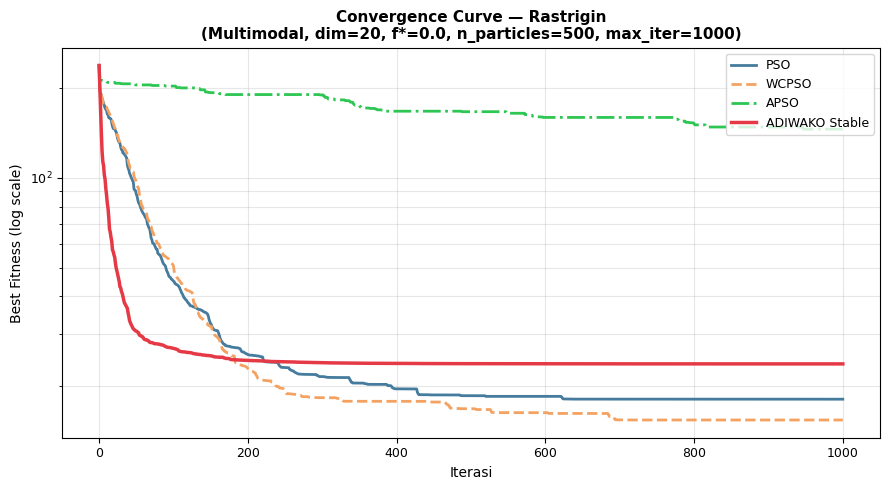


[2/10] Styblinski-Tang
  Fungsi: Styblinski-Tang | dim=2 |  type=Multimodal | f*=-78.332
    PSO              |  Best: -7.8332e+01 |  Mean: -7.8332e+01 |  Std:  0.0000e+00
    WCPSO            |  Best: -7.8332e+01 |  Mean: -7.8332e+01 |  Std:  0.0000e+00
    APSO             |  Best: -7.8332e+01 |  Mean: -7.8332e+01 |  Std:  0.0000e+00
    ADIWAKO Stable   |  Best: -7.8332e+01 |  Mean: -7.8332e+01 |  Std:  0.0000e+00
  Excel disimpan: Styblinski-Tang_2D1000iter_Function.xlsx


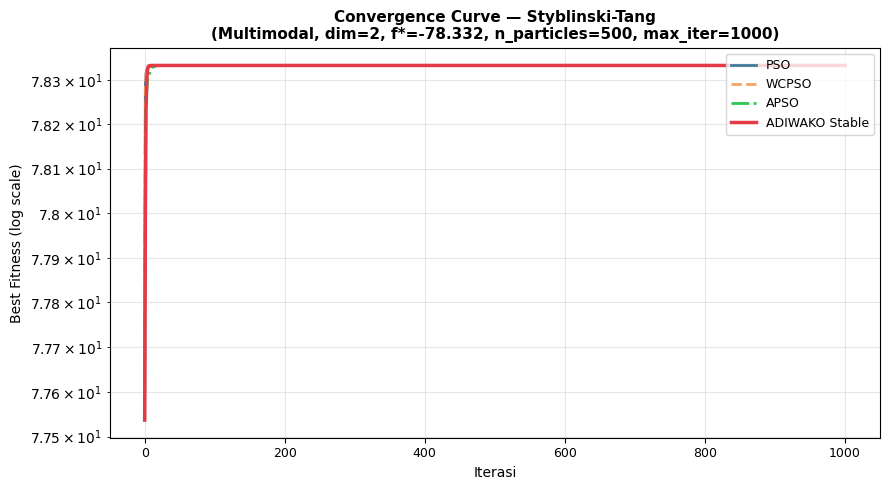


[3/10] Levy-N13
  Fungsi: Levy-N13 | dim=2 |  type=Multimodal | f*=0.0
    PSO              |  Best:  1.3498e-31 |  Mean:  1.3498e-31 |  Std:  0.0000e+00
    WCPSO            |  Best:  1.3498e-31 |  Mean:  1.3498e-31 |  Std:  0.0000e+00
    APSO             |  Best:  2.8371e-06 |  Mean:  6.0951e-05 |  Std:  7.3329e-05
    ADIWAKO Stable   |  Best:  9.5384e-30 |  Mean:  4.0565e-27 |  Std:  8.1311e-27
  Excel disimpan: Levy-N13_2D1000iter_Function.xlsx


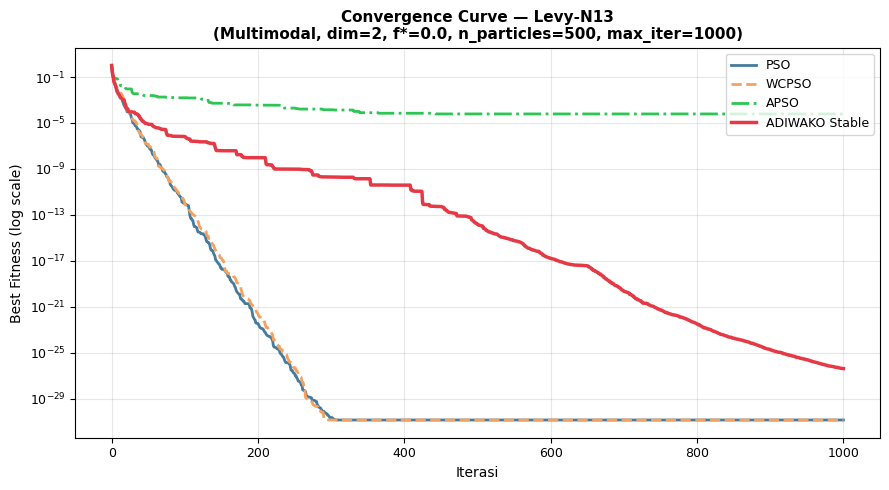


[4/10] Schwefel-2.22
  Fungsi: Schwefel-2.22 | dim=20 |  type=Unimodal | f*=0.0
    PSO              |  Best:  1.6447e-25 |  Mean:  1.0914e-24 |  Std:  7.0557e-25
    WCPSO            |  Best:  1.8300e-25 |  Mean:  1.0018e-24 |  Std:  6.2238e-25
    APSO             |  Best:  4.6951e+01 |  Mean:  6.6982e+01 |  Std:  1.8342e+01
    ADIWAKO Stable   |  Best:  2.1877e-02 |  Mean:  4.6527e-02 |  Std:  2.3313e-02
  Excel disimpan: Schwefel-2.22_20D1000iter_Function.xlsx


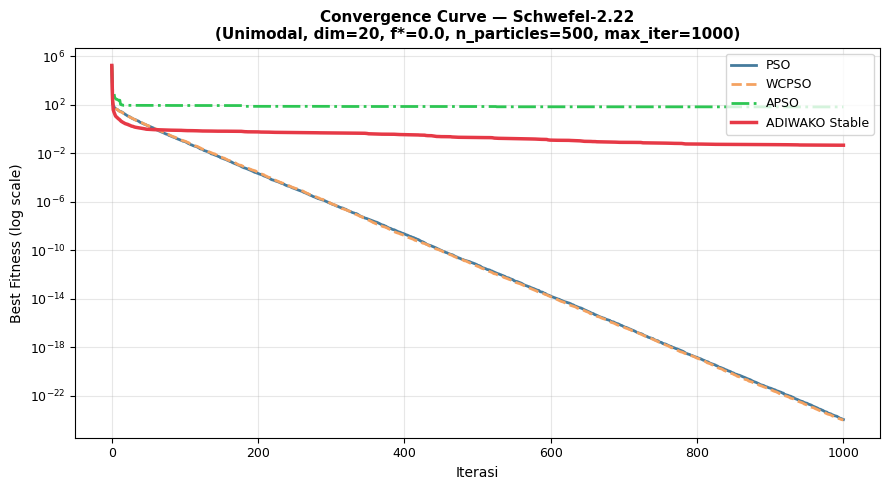


[5/10] Michalewicz
  Fungsi: Michalewicz | dim=10 |  type=Multimodal | f*=-9.66
    PSO              |  Best: -9.4438e+00 |  Mean: -8.9230e+00 |  Std:  3.8975e-01
    WCPSO            |  Best: -9.5724e+00 |  Mean: -8.9261e+00 |  Std:  5.1154e-01
    APSO             |  Best: -9.3056e+00 |  Mean: -7.3391e+00 |  Std:  1.4365e+00
    ADIWAKO Stable   |  Best: -9.0534e+00 |  Mean: -8.1557e+00 |  Std:  5.0260e-01
  Excel disimpan: Michalewicz_10D1000iter_Function.xlsx


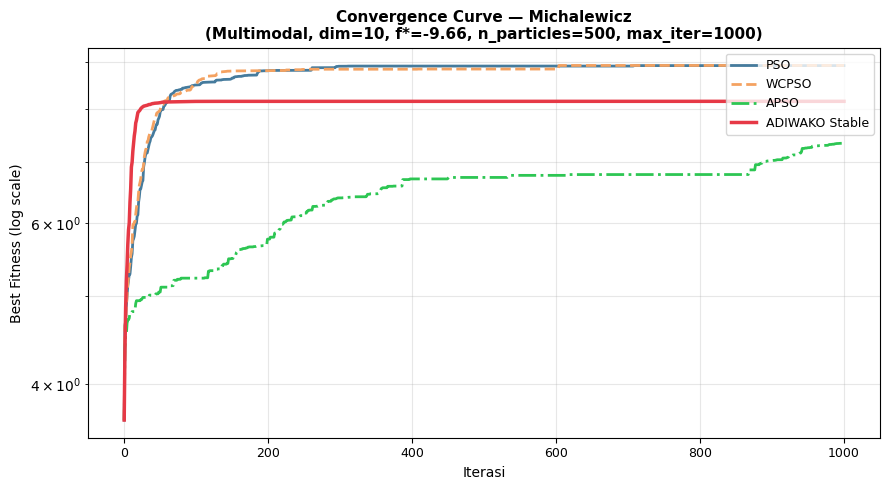


[6/10] Zakharov
  Fungsi: Zakharov | dim=20 |  type=Unimodal | f*=0.0
    PSO              |  Best:  7.9179e-16 |  Mean:  4.9433e-14 |  Std:  6.0457e-14
    WCPSO            |  Best:  5.3783e-15 |  Mean:  3.0764e-13 |  Std:  5.9161e-13
    APSO             |  Best:  9.8513e+01 |  Mean:  1.3516e+02 |  Std:  2.1475e+01
    ADIWAKO Stable   |  Best:  3.2935e-01 |  Mean:  4.4425e-01 |  Std:  8.4055e-02
  Excel disimpan: Zakharov_20D1000iter_Function.xlsx


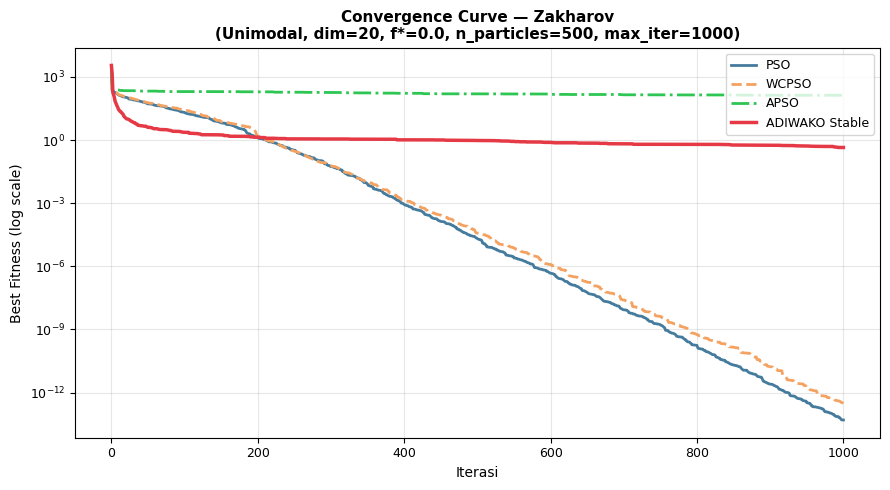


[7/10] Ackley
  Fungsi: Ackley | dim=20 |  type=Multimodal | f*=0.0
    PSO              |  Best:  3.9968e-15 |  Mean:  6.4837e-15 |  Std:  1.6281e-15
    WCPSO            |  Best:  7.5495e-15 |  Mean:  7.5495e-15 |  Std:  0.0000e+00
    APSO             |  Best:  4.7103e+00 |  Mean:  5.6164e+00 |  Std:  7.3866e-01
    ADIWAKO Stable   |  Best:  3.2203e-02 |  Mean:  9.0742e-01 |  Std:  7.4041e-01
  Excel disimpan: Ackley_20D1000iter_Function.xlsx


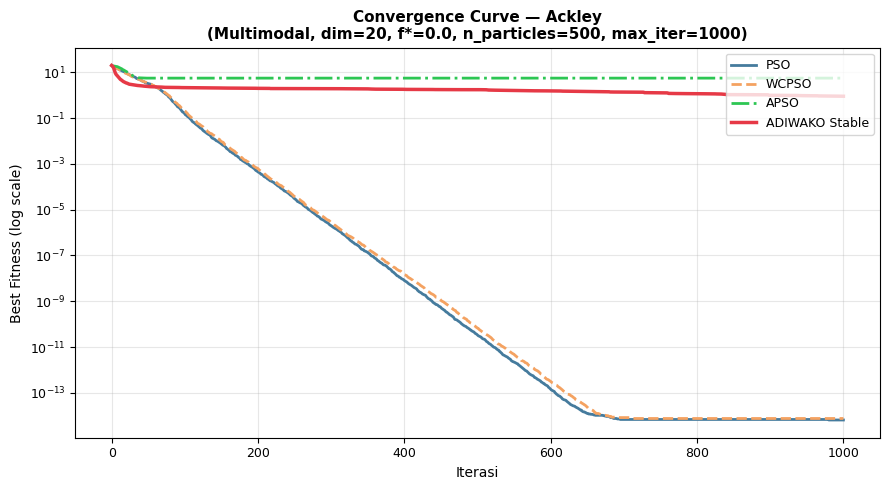


[8/10] Alpine
  Fungsi: Alpine | dim=10 |  type=Multimodal | f*=0.0
    PSO              |  Best:  3.7795e-41 |  Mean:  2.2038e-15 |  Std:  2.3221e-15
    WCPSO            |  Best:  1.1272e-34 |  Mean:  1.8929e-15 |  Std:  2.3335e-15
    APSO             |  Best:  1.7678e+00 |  Mean:  4.2007e+00 |  Std:  1.0179e+00
    ADIWAKO Stable   |  Best:  1.2366e-04 |  Mean:  1.1214e-03 |  Std:  1.1889e-03
  Excel disimpan: Alpine_10D1000iter_Function.xlsx


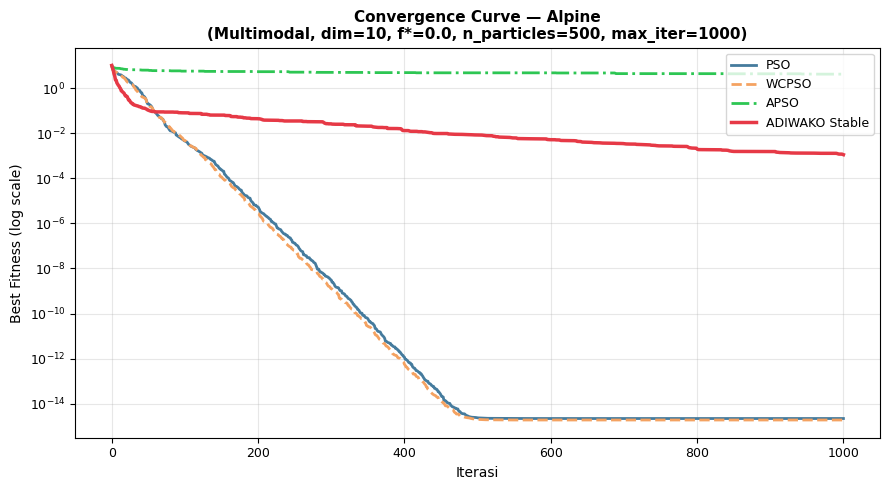


[9/10] Beales
  Fungsi: Beales | dim=2 |  type=Multimodal | f*=0.0
    PSO              |  Best:  0.0000e+00 |  Mean:  0.0000e+00 |  Std:  0.0000e+00
    WCPSO            |  Best:  0.0000e+00 |  Mean:  0.0000e+00 |  Std:  0.0000e+00
    APSO             |  Best:  8.9792e-09 |  Mean:  7.2700e-07 |  Std:  1.0047e-06
    ADIWAKO Stable   |  Best:  5.1029e-30 |  Mean:  6.5603e-23 |  Std:  1.9035e-22
  Excel disimpan: Beales_2D1000iter_Function.xlsx


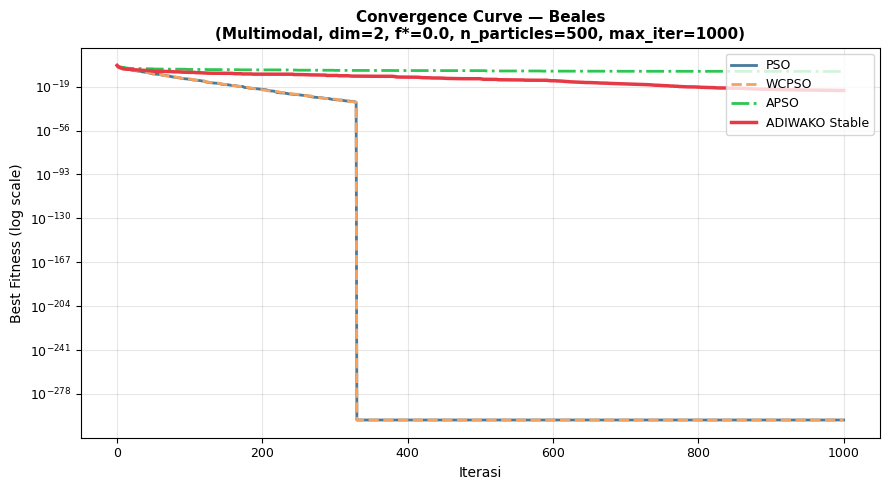


[10/10] Booths
  Fungsi: Booths | dim=2 |  type=Unimodal | f*=0.0
    PSO              |  Best:  0.0000e+00 |  Mean:  0.0000e+00 |  Std:  0.0000e+00
    WCPSO            |  Best:  0.0000e+00 |  Mean:  0.0000e+00 |  Std:  0.0000e+00
    APSO             |  Best:  5.2800e-07 |  Mean:  1.4026e-05 |  Std:  1.8388e-05
    ADIWAKO Stable   |  Best:  3.1554e-30 |  Mean:  1.8698e-27 |  Std:  2.2087e-27
  Excel disimpan: Booths_2D1000iter_Function.xlsx


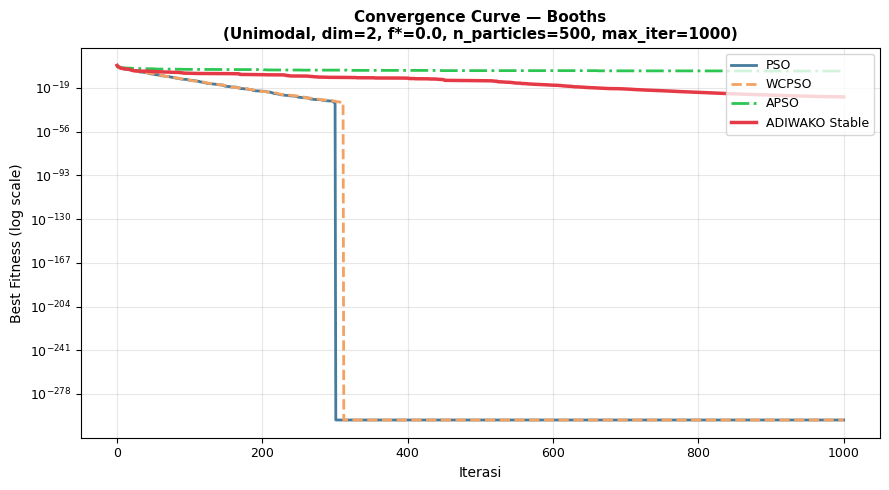


SEMUA EKSPERIMEN SELESAI
File Excel yang dibuat (10):
  - Rastrigin_20D1000iter_Function.xlsx
  - Styblinski-Tang_2D1000iter_Function.xlsx
  - Levy-N13_2D1000iter_Function.xlsx
  - Schwefel-2.22_20D1000iter_Function.xlsx
  - Michalewicz_10D1000iter_Function.xlsx
  - Zakharov_20D1000iter_Function.xlsx
  - Ackley_20D1000iter_Function.xlsx
  - Alpine_10D1000iter_Function.xlsx
  - Beales_2D1000iter_Function.xlsx
  - Booths_2D1000iter_Function.xlsx


In [7]:
# ══════════════════════════════════════════════════════════
# EKSEKUSI UTAMA
# ══════════════════════════════════════════════════════════

# Validasi benchmark terhadap BENCHMARK_REGISTRY
valid_selected = [b for b in selected_benchmarks if b in BENCHMARK_REGISTRY]
invalid        = [b for b in selected_benchmarks if b not in BENCHMARK_REGISTRY]
if invalid:
    print(f'PERINGATAN: benchmark tidak dikenal dilewati: {invalid}')
selected_benchmarks = valid_selected

saved_files    = []
all_summaries  = []

total = len(selected_benchmarks)

for bench_idx, bench_name in enumerate(selected_benchmarks, 1):
    bench_cfg = BENCHMARK_REGISTRY[bench_name]
    print()
    print(f'{'='*65}')
    print(f'[{bench_idx}/{total}] {bench_name}')
    print(f'{'='*65}')

    # ── 1. Jalankan eksperimen ─────────────────────────────
    all_run_results, all_mean_history = run_experiment(
        bench_name  = bench_name,
        bench_cfg   = bench_cfg,
        algo_configs= ALGO_CONFIGS,
        n_runs      = N_RUNS,
        n_particles = N_PARTICLES,
        max_iter    = MAX_ITER,
    )

    # ── 2. Export ke Excel ────────────────────────────────
    fname = export_to_excel(
        bench_name      = bench_name,
        bench_cfg       = bench_cfg,
        all_run_results = all_run_results,
        max_iter        = MAX_ITER,
    )
    saved_files.append(fname)
    print(f'  Excel disimpan: {fname}')

    # ── 3. Tampilkan grafik konvergensi ──────────────────
    plot_convergence(
        bench_name       = bench_name,
        bench_cfg        = bench_cfg,
        all_mean_history = all_mean_history,
        max_iter         = MAX_ITER,
    )

    # ── 4. Kumpulkan ringkasan ────────────────────────────
    for algo_name, run_results in all_run_results.items():
        fits = [r['fitness'] for r in run_results]
        all_summaries.append({
            'Benchmark'  : bench_name,
            'Dim'        : bench_cfg['n_dim'],
            'Type'       : bench_cfg['type'],
            'Algorithm'  : algo_name,
            'Best'       : min(fits),
            'Mean'       : np.mean(fits),
            'Std'        : np.std(fits),
            'Avg Time(s)': np.mean([r['exec_time'] for r in run_results]),
            'Avg Conv'   : np.mean([r['conv_iter'] for r in run_results]),
        })


print()
print('='*65)
print('SEMUA EKSPERIMEN SELESAI')
print('='*65)
print(f'File Excel yang dibuat ({len(saved_files)}):')
for f in saved_files:
    print(f'  - {f}')

---
## BAGIAN 7: Tabel Ringkasan Hasil

In [8]:
# ── Tabel ringkasan semua hasil ──────────────────────────
df_summary = pd.DataFrame(all_summaries)

print('=== RINGKASAN HASIL SEMUA BENCHMARK ===')
print()
print(df_summary[['Benchmark','Algorithm','Best','Mean','Std',
                   'Avg Time(s)','Avg Conv']].to_string(index=False))

# ── Tabel pemenang per benchmark ─────────────────────────
print()
print('=== BEST ALGORITHM PER BENCHMARK (berdasarkan Mean Fitness) ===')
print(f'  {"Benchmark":<18} {"Best Algo":<18} {"Mean Fitness":>14} {"Std":>12}')
print('  ' + '-'*65)

for bench_name in selected_benchmarks:
    bench_data = df_summary[df_summary['Benchmark'] == bench_name]
    if bench_data.empty:
        continue
    best_row = bench_data.loc[bench_data['Mean'].idxmin()]
    print(f'  {bench_name:<18} {best_row["Algorithm"]:<18} '
          f'{best_row["Mean"]:>14.4e} {best_row["Std"]:>12.4e}')

# ── Skor kemenangan keseluruhan ───────────────────────────
print()
print('=== TOTAL KEMENANGAN (Best Mean per Benchmark) ===')
win_count = {name: 0 for name, _, _ in ALGO_CONFIGS}
for bench_name in selected_benchmarks:
    bench_data = df_summary[df_summary['Benchmark'] == bench_name]
    if bench_data.empty: continue
    winner = bench_data.loc[bench_data['Mean'].idxmin(), 'Algorithm']
    if winner in win_count:
        win_count[winner] += 1

for algo, count in sorted(win_count.items(), key=lambda x: -x[1]):
    bar = '█' * count
    print(f'  {algo:<18}: {count:>2} kemenangan  {bar}')

=== RINGKASAN HASIL SEMUA BENCHMARK ===

      Benchmark      Algorithm          Best          Mean          Std  Avg Time(s)  Avg Conv
      Rastrigin            PSO  5.969754e+00  1.811531e+01 1.031248e+01     1.393308     697.4
      Rastrigin          WCPSO  5.969754e+00  1.542895e+01 1.075487e+01     1.379275     753.0
      Rastrigin           APSO  8.666260e+01  1.454713e+02 4.089491e+01     1.385897     388.5
      Rastrigin ADIWAKO Stable  1.593203e+01  2.378241e+01 5.308410e+00     1.398113    1000.0
Styblinski-Tang            PSO -7.833233e+01 -7.833233e+01 0.000000e+00     1.512249     131.2
Styblinski-Tang          WCPSO -7.833233e+01 -7.833233e+01 0.000000e+00     1.501694     137.3
Styblinski-Tang           APSO -7.833233e+01 -7.833233e+01 0.000000e+00     1.482051      68.8
Styblinski-Tang ADIWAKO Stable -7.833233e+01 -7.833233e+01 0.000000e+00     1.524940      37.8
       Levy-N13            PSO  1.349784e-31  1.349784e-31 0.000000e+00     0.799794     295.8
       Le

---
## BAGIAN 8: Download File Excel

In [9]:
# ══════════════════════════════════════════════════════════
# DOWNLOAD FILE EXCEL — PILIH SALAH SATU
# ══════════════════════════════════════════════════════════

# Tampilkan daftar file yang tersedia
print('File Excel yang tersedia:')
for i, f in enumerate(saved_files):
    print(f'  [{i}] {f}')

# ── PILIH FILE YANG INGIN DIDOWNLOAD ──────────────────────
# Ganti angka di bawah sesuai nomor file yang ingin didownload
# Contoh: pilih_index = 0  --> download file pertama
#         pilih_index = 2  --> download file ketiga

pilih_index = 0   # <-- UBAH ANGKA INI

# ─────────────────────────────────────────────────────────
if pilih_index < 0 or pilih_index >= len(saved_files):
    print(f'\nINDEX TIDAK VALID! Pilih antara 0 sampai {len(saved_files)-1}')
else:
    file_dipilih = saved_files[pilih_index]
    print(f'\nFile yang akan didownload: {file_dipilih}')

    try:
        from google.colab import files
        files.download(file_dipilih)
        print(f'Berhasil didownload: {file_dipilih}')
    except ImportError:
        import os
        print(f'Bukan Google Colab.')
        print(f'File tersimpan di: {os.path.abspath(file_dipilih)}')

File Excel yang tersedia:
  [0] Rastrigin_20D1000iter_Function.xlsx
  [1] Styblinski-Tang_2D1000iter_Function.xlsx
  [2] Levy-N13_2D1000iter_Function.xlsx
  [3] Schwefel-2.22_20D1000iter_Function.xlsx
  [4] Michalewicz_10D1000iter_Function.xlsx
  [5] Zakharov_20D1000iter_Function.xlsx
  [6] Ackley_20D1000iter_Function.xlsx
  [7] Alpine_10D1000iter_Function.xlsx
  [8] Beales_2D1000iter_Function.xlsx
  [9] Booths_2D1000iter_Function.xlsx

File yang akan didownload: Rastrigin_20D1000iter_Function.xlsx
Bukan Google Colab.
File tersimpan di: /Users/rosanuralianasawafi/Downloads/Rastrigin_20D1000iter_Function.xlsx
